# 📊 01. Injury vs Non-Injury Distribution (Task A)
### PLAYHACK — Athlete Health & Biometric Injury Prediction

This notebook investigates the target class balance for **Task A: Binary Injury Prediction (`injured_in_risk_window`)** across all 3,000 athletes in the dataset, including breakdowns by sport, gender, and prior injury history.

---

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica, Arial, sans-serif'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Resolve data paths
data_dir = '../data' if os.path.exists('../data') else 'data'
outputs_dir = '../outputs' if os.path.exists('../outputs') else 'outputs'

# Load datasets
labels_df = pd.read_csv(os.path.join(data_dir, 'train_labels.csv'))
meta_df = pd.read_csv(os.path.join(data_dir, 'athlete_metadata.csv'))
merged_df = pd.merge(labels_df, meta_df, on='athlete_id')

print(f"Total Athletes: {len(merged_df):,}")
print(f"Dataset Columns: {list(merged_df.columns)}")

Total Athletes: 3,000
Dataset Columns: ['athlete_id', 'injured_in_risk_window', 'onset_day_offset', 'recovery_duration', 'sport', 'age', 'gender', 'height_cm', 'weight_kg_baseline', 'dominant_side', 'years_playing', 'position', 'team_id', 'prior_season_injury_count']


## 1. Class Distribution Statistics

In [2]:
counts = merged_df['injured_in_risk_window'].value_counts()
proportions = merged_df['injured_in_risk_window'].value_counts(normalize=True) * 100

stats_df = pd.DataFrame({
    'Status': ['Non-Injured (0)', 'Injured (1)'],
    'Athlete Count': [counts.get(0, 0), counts.get(1, 0)],
    'Percentage (%)': [proportions.get(0, 0), proportions.get(1, 0)]
})
stats_df.set_index('Status', inplace=True)
display(stats_df)

,Athlete Count,Percentage (%)
Status,,
Non-Injured (0),1950,65.0
Injured (1),1050,35.0


## 2. Target Distribution Visualization

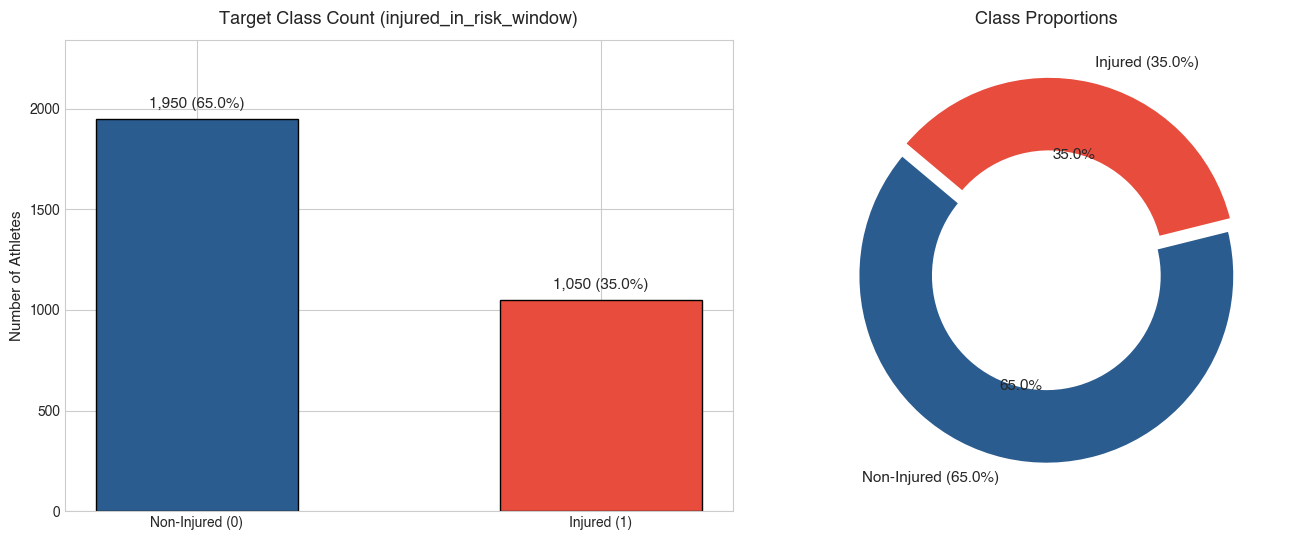

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# 1. Bar Chart with Annotations
colors = ['#2b5c8f', '#e74c3c']
bars = axes[0].bar(['Non-Injured (0)', 'Injured (1)'], [counts[0], counts[1]], color=colors, width=0.5, edgecolor='black', linewidth=1)
axes[0].set_title('Target Class Count (injured_in_risk_window)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel('Number of Athletes', fontsize=11)
axes[0].set_ylim(0, max(counts) * 1.2)

for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 40,
                 f"{int(height):,} ({height/len(merged_df)*100:.1f}%)",
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. Donut Chart
axes[1].pie([counts[0], counts[1]], labels=['Non-Injured (65.0%)', 'Injured (35.0%)'],
            colors=colors, autopct='%1.1f%%', startangle=140, explode=(0, 0.06),
            textprops={'fontsize': 11, 'fontweight': 'bold'}, wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2))
axes[1].set_title('Class Proportions', fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

## 3. Injury Distribution Breakdown by Sport & Prior History

/var/folders/rl/jjspnqnn4d7d0b7r1v032g7c0000gn/T/ipykernel_2509/1006149609.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sport_injury, x='sport', y='mean', palette='Blues_r', ax=axes[0], edgecolor='black')
/var/folders/rl/jjspnqnn4d7d0b7r1v032g7c0000gn/T/ipykernel_2509/1006149609.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prior_injury, x='prior_season_injury_count', y='mean', palette='Reds_r', ax=axes[1], edgecolor='black')


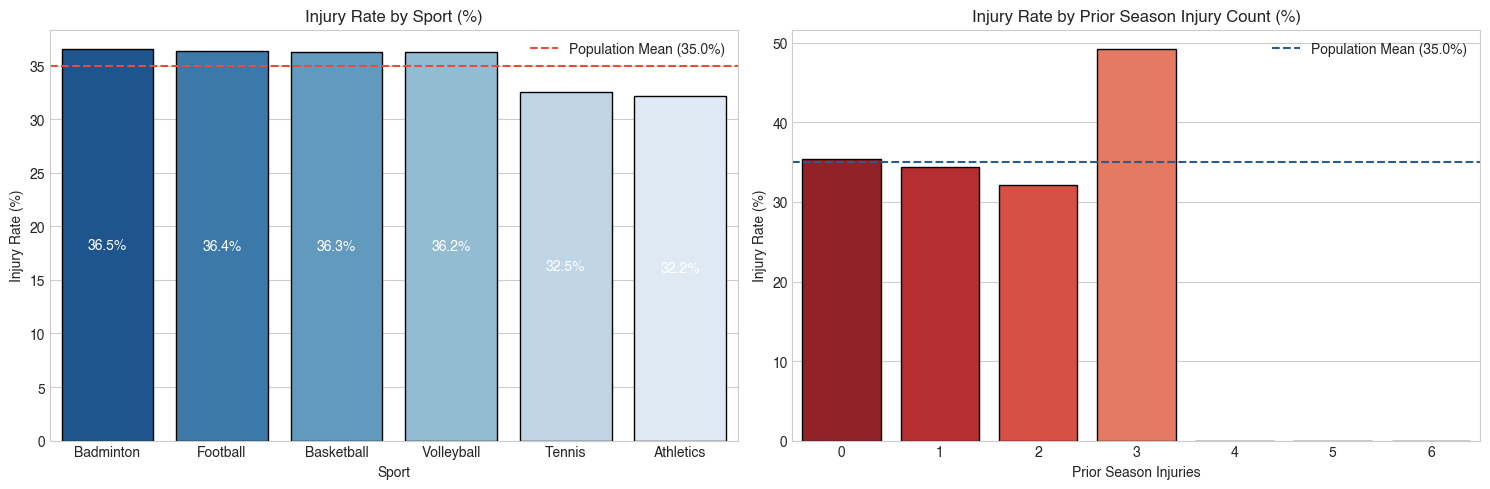

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# By Sport
sport_injury = merged_df.groupby('sport')['injured_in_risk_window'].agg(['count', 'mean']).reset_index()
sport_injury['mean'] = sport_injury['mean'] * 100
sport_injury = sport_injury.sort_values(by='mean', ascending=False)

sns.barplot(data=sport_injury, x='sport', y='mean', palette='Blues_r', ax=axes[0], edgecolor='black')
axes[0].set_title('Injury Rate by Sport (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Injury Rate (%)', fontsize=10)
axes[0].set_xlabel('Sport', fontsize=10)
axes[0].axhline(35.0, color='#e74c3c', linestyle='--', label='Population Mean (35.0%)')
axes[0].legend()
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', fontsize=10, color='white' if p.get_height() > 30 else 'black', fontweight='bold')

# By Prior Season Injury Count
prior_injury = merged_df.groupby('prior_season_injury_count')['injured_in_risk_window'].agg(['count', 'mean']).reset_index()
prior_injury['mean'] = prior_injury['mean'] * 100

sns.barplot(data=prior_injury, x='prior_season_injury_count', y='mean', palette='Reds_r', ax=axes[1], edgecolor='black')
axes[1].set_title('Injury Rate by Prior Season Injury Count (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Injury Rate (%)', fontsize=10)
axes[1].set_xlabel('Prior Season Injuries', fontsize=10)
axes[1].axhline(35.0, color='#2b5c8f', linestyle='--', label='Population Mean (35.0%)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 💡 Key Analytical Insight

> **Insight**: The dataset exhibits a **65.0% non-injured vs 35.0% injured class balance** (1,950 non-injured vs 1,050 injured athletes). Because a baseline majority-class classifier achieves 65.0% accuracy with zero real-world utility, predictive modeling must focus on **threshold-tuned F1 Score** and precision-recall optimization to accurately detect high-risk athletes across all sport disciplines.
